# Glaciers — quickstart (live)

The [`glaciers`](../../reference/glaciers/introduction.md) backend fetches glacier **outlines** and **fluctuations** from three open sources and returns them in the natural shape for each: a pyramids `FeatureCollection` for outlines (RGI 7.0, GLIMS) and a `pandas.DataFrame` for fluctuations (WGMS).

This quickstart pulls **RGI 7.0 glacier outlines** for a small bounding box over the French Alps and draws them on a map. By the end you will know how to request outlines for an area of interest and what the result looks like.

All three sources are **open** — no account, no API key.

## Setup

We need the `EarthLens` facade and `matplotlib`. The backend caches its downloads under `path/_glaciers_cache/`; we point `path=` at a throwaway temp directory so this notebook leaves nothing behind.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
from earthlens.core import EarthLens

workdir = Path(tempfile.mkdtemp(prefix='glaciers-'))
workdir

WindowsPath('C:/Users/main/AppData/Local/Temp/glaciers-d1xzyep8')

## Request RGI outlines for a bounding box

Pick the dataset with `variables=['rgi:outlines']` and pass a bounding box as `lat_lim` / `lon_lim`. Behind the scenes the backend maps the bbox to the overlapping GTN-G region (here region 11, *Central Europe*), downloads that region's shapefile once, reads it with pyramids, and clips it to your box. The result is a `FeatureCollection` (a `GeoDataFrame`) in EPSG:4326.

In [2]:
fc = EarthLens(
    data_source='glaciers',
    variables=['rgi:outlines'],
    lat_lim=[45.8, 46.05],
    lon_lim=[6.8, 7.2],  # a small box over the Mont Blanc area
    path=workdir,
).download()

type(fc).__name__, len(fc), str(fc.crs)

2026-06-28 17:54:47 | INFO | pyramids.base.config | Logging is configured.


2026-06-28 17:54:51.898 | INFO     | earthlens.glaciers.backend:_log_citation:442 - Glaciers source citation: RGI 7.0 Consortium (2023), Randolph Glacier Inventory 7.0, DOI 10.5067/F6JMOVY5NAVZ (CC-BY-4.0); open mirror UNESCO IHP-WINS.


2026-06-28 17:54:51.902 | INFO     | earthlens.glaciers.backend:download:392 - Glaciers rgi:outlines: returned a FeatureCollection (122 outline(s)).


('FeatureCollection', 122, 'EPSG:4326')

Each row is one glacier. The attribute table carries the RGI id, the glacier name, its area, and elevation statistics — let's peek at a few columns.

In [3]:
fc[['rgi_id', 'glac_name', 'area_km2', 'zmin_m', 'zmax_m']].head()

,rgi_id,glac_name,area_km2,zmin_m,zmax_m
677,RGI2000-v7.0-G-11-00678,FR4N01239D01 de Tre la Tete,8.363138,1999.6450,3840.4348
683,RGI2000-v7.0-G-11-00684,FR4N01239B04 du Miage 3,0.622232,2776.2400,3628.9830
684,RGI2000-v7.0-G-11-00685,Dòmes de Miage,0.060713,3420.6409,3646.4211
685,RGI2000-v7.0-G-11-00686,Col de Miage,0.126005,3032.3823,3433.2537
686,RGI2000-v7.0-G-11-00687,None,0.193162,3137.2896,3437.0890


## Visualise the outlines

Because a `FeatureCollection` is a `GeoDataFrame`, we can draw it directly. We shade each glacier by its area so the larger ice bodies stand out.

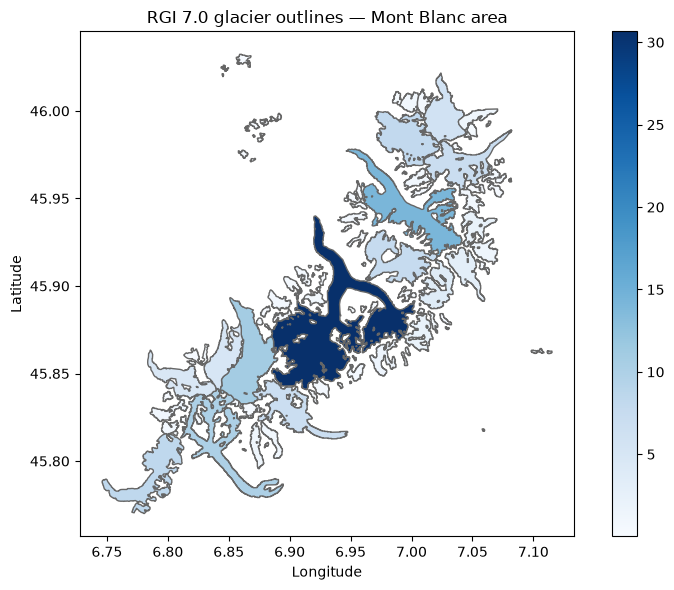

In [4]:
ax = fc.plot(
    column='area_km2',
    cmap='Blues',
    edgecolor='0.4',
    legend=True,
    figsize=(8, 6),
)
ax.set_title('RGI 7.0 glacier outlines — Mont Blanc area')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

The polygons are the real RGI 7.0 glacier outlines clipped to our box — the large blue body near the centre is the Mer de Glace / Mont Blanc glacier complex. The total glacierised area in view:

In [5]:
round(float(fc['area_km2'].sum()), 1)  # km^2 of ice in the bbox

160.3

## Takeaway

One `EarthLens(...).download()` call returns ready-to-map glacier outlines clipped to your area of interest. Next:

- [Catalog & behaviour](02_catalog_and_behavior.ipynb) — the datasets, the GTN-G regions, the per-instance output shape, and why `aggregate=` is rejected (no network).
- [GLIMS & WGMS](03_glims_and_wgms.ipynb) — time-series outlines and the mass-balance record.